# Explication de la Méthode pour Choisir K dans K-Means:  
- Deux méthodes principales sont utilisées ici :  
- - La Méthode du Coude (Elbow Method) → Basée sur l’inertie.  
- - Le Score de Silhouette → Mesure la qualité des clusters.  

### 1. Méthode du Coude (Inertie / Variance Totale)  
L’inertie (kmeans.inertia_) mesure la somme des distances au carré entre chaque point et son centroïde.  
Plus l’inertie est faible, plus les clusters sont compacts (bons).  
Quand K augmente, l’inertie diminue (car les clusters deviennent plus petits).  
#### ***Principe de la Méthode du Coude***  
On cherche le point où l’inertie ne diminue plus significativement (un "coude" dans la courbe).  
Ce point suggère que ajouter plus de clusters n’améliore plus significativement le modèle.  

### 2. Score de Silhouette  
Le score (silhouette_score) mesure :  
Cohésion (a) → Distance moyenne d’un point aux autres points de son cluster.  
Séparation (b) → Distance moyenne d’un point aux points du cluster le plus proche.  
Score = (b - a) / max(a, b) → Entre -1 (mauvais) et +1 (excellent).  
#### ***Interprétation***  
Score élevé (proche de 1) → Clusters bien séparés et denses.  
Score faible (proche de 0 ou négatif) → Chevauchement des clusters.  


## 1- import the libraries:

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

## 2- Load the data:

In [ ]:
df=pd.read_csv('GENERAL.csv').fillna(0)
# Extract Customer IDs (non-numeric column)
customer_ids = df.iloc[:, 0]  # Assuming 1st column is ID

# Extract numerical features (all columns except the first)
X = df.iloc[:, 1:].values  # Or: X = data.drop(columns=[data.columns[0]])
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,0.000000,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## 3- visualise the data:  
not necessary, just to take a look into my data

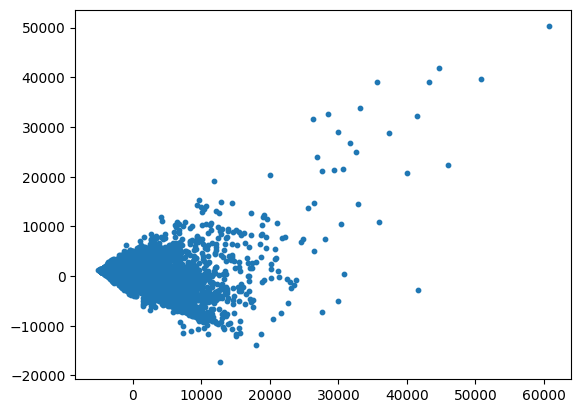

In [8]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)  # Reduce to 2D
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)      # Plot
plt.show() 

## 4- Standardise the data:  
La standardisation est cruciale pour K-Means car :  
- Égalise l’influence des variables (évite qu’une feature à grande échelle domine).  
- Rend les distances comparables (ex: âge vs revenu).  
- Améliore la convergence (des clusters plus équilibrés).  

Sans elle, les résultats seraient faussés par les unités de mesure (ex: des clusters basés uniquement sur le revenu car 50 000 > 30 ans)

In [9]:
# Scale ONLY numeric columns (excluding Customer ID if needed)
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = StandardScaler().fit_transform(df[numeric_cols])

# Verify
print(df.head())

  CUST_ID   BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
0  C10001 -0.731989          -0.249434  -0.424900         -0.356934   
1  C10002  0.786961           0.134325  -0.469552         -0.356934   
2  C10003  0.447135           0.518084  -0.107668          0.108889   
3  C10004  0.049099          -1.016953   0.232058          0.546189   
4  C10005 -0.358775           0.518084  -0.462063         -0.347294   

   INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
0               -0.349079     -0.466786            -0.806490   
1               -0.454576      2.605605            -1.221758   
2               -0.454576     -0.466786             1.269843   
3               -0.454576     -0.368653            -1.014125   
4               -0.454576     -0.466786            -1.014125   

   ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
0                   -0.678661                         -0.707313   
1                   -0.678661                         

## 5- Find the most optimal k value using a loop:  

In [ ]:
TotVar = [] # Stocker les valeurs d'inertie pour chaque K
Silhouette=[] # Stocker les scores de silhouette pour chaque K

# Start and End Points of K values
StartK = 2# Nombre minimum de clusters à tester
Endk= 15
#Loop to calculate variance and silhouette score by K cluster 
for K in range(StartK, Endk):
    kmeans=KMeans (n_clusters=K, init="k-means++", n_init="auto", random_state=0) 
    kmeans.fit(df[numeric_cols])
    labels=kmeans.labels_
    Silhouette.append(silhouette_score (df[numeric_cols], labels))
    TotVar.append(kmeans.inertia_)

### 5- A.plot the outputs: elbow plot:

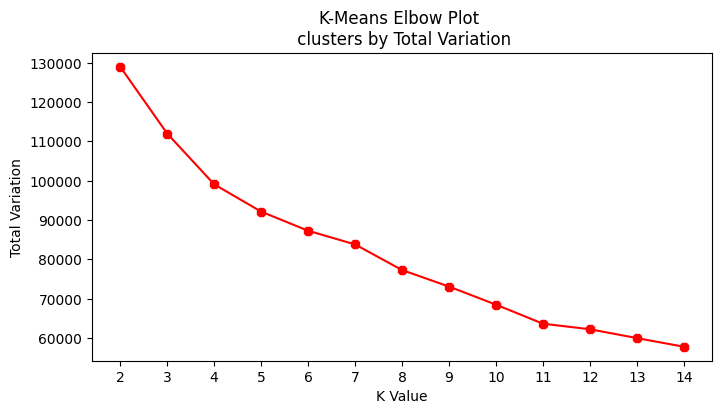

In [12]:
plt.figure(figsize = (8, 4))
plt.plot(range(StartK, Endk), TotVar, color="red", marker ="8") 
plt.xlabel("K Value")
plt.xticks(np.arange(StartK, Endk,1))
plt.ylabel("Total Variation")
plt.title("K-Means Elbow Plot \n clusters by Total Variation")
plt.show()

### 5- B. plot results: silhouette plot:

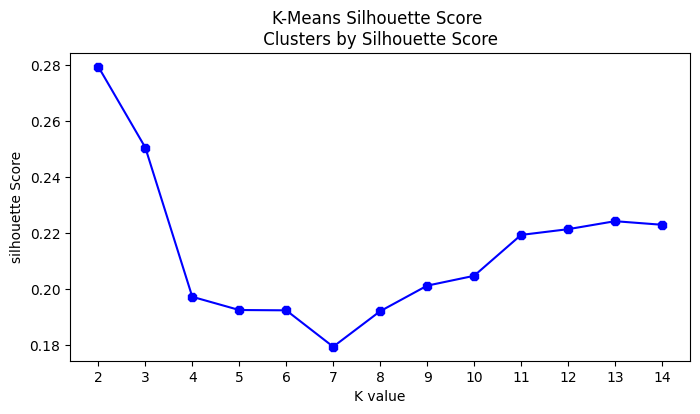

In [13]:

plt.figure(figsize = (8, 4))
plt.plot(range(StartK, Endk), Silhouette, color="blue", marker ="8") 
plt.xlabel("K value")
plt.xticks(np.arange(StartK, Endk,1))
plt.ylabel("silhouette Score")
plt.title("K-Means Silhouette Score \n Clusters by Silhouette Score ")
plt.show()

### 5- C. table format of the result:

In [15]:
LoopResults=pd.DataFrame(np.arange(StartK, Endk,1), columns=["K Value"]) 
LoopResults["Total Variation"] = TotVar
LoopResults["silhouette Score"] = Silhouette
print (LoopResults) 

    K Value  Total Variation  silhouette Score
0         2    128950.898656          0.279552
1         3    111967.372789          0.250614
2         4     99055.931311          0.197179
3         5     92116.832098          0.192442
4         6     87252.275637          0.192330
5         7     83770.304558          0.179301
6         8     77261.104919          0.192017
7         9     73058.974756          0.201163
8        10     68460.275363          0.204690
9        11     63616.126922          0.219328
10       12     62205.460705          0.221383
11       13     59959.260704          0.224247
12       14     57763.263488          0.222965


- we take the value of k in which the elbow graph starts to become stable.
- if we cant tell using the elbow graph, we take the value of k in which the silhoute is the highest.
- in our case, for this data set, k=2.

## 6- Create the final kmeans using k=2 clusters:

In [ ]:
kmeans=KMeans (n_clusters = 2 ,
               init="k-means++" ,# Méthode optimisée pour l'initialisation des centroides
               n_init="auto",random_state= 0)
kmeans.fit(df[numeric_cols])

KMeans(n_clusters=2, random_state=0)

## 7- Create the clusters and add the clusters to the dataset:

In [18]:

df["clusters"] = kmeans.fit_predict(df [numeric_cols]) 
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,clusters
0,C10001,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960213,-0.528979,-0.297310,-0.525551,0.36068,1
1,C10002,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688718,0.818642,0.102042,0.234227,0.36068,1
2,C10003,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826129,-0.383805,-0.088489,-0.525551,0.36068,0
3,C10004,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826129,-0.598688,-0.357035,-0.525551,0.36068,1
4,C10005,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905249,-0.364368,-0.252238,-0.525551,0.36068,1


## 8- Visualise the clusters:

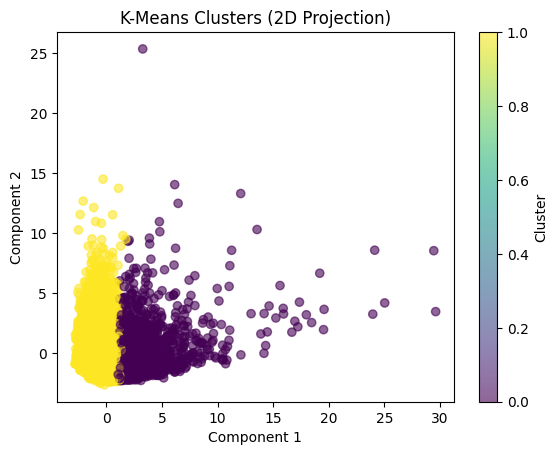

In [ ]:
# Extract numeric data (excluding 'clusters' column)
X = df[numeric_cols]  

# Reduce to 2D (PCA for speed, t-SNE for better separation)
X_2d = PCA(n_components=2).fit_transform(X)  # or TSNE(n_components=2).fit_transform(X)

# Plot clusters
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=df["clusters"], cmap="viridis", alpha=0.6)
plt.title("K-Means Clusters (2D Projection)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar(label="Cluster")
plt.show()